In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

# Load the old CNN

In [2]:
# Use metal performance shaders (MPS) if available

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Usando dispositivo:", device)

#Load the model and configure for the device


model_path = "Models/Model_Exec_720_Epoch_150_cpu_portable.pth"

values = torch.load(model_path, map_location="cpu", weights_only=False)
model = values["modelo"]

model = model.to(device)
model.eval()

print("Modelo cargado correctamente")
print(model)


Usando dispositivo: mps
Modelo cargado correctamente
CNN(
  (extraction): Sequential(
    (0): Conv2d(1, 128, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(128, 8, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(16, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

# Capture the tensor and get the vector

In [3]:
#Tensor from model to vector[1024] extracter:

class CNNEmbeddingExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()

        self.features = nn.ModuleList([
            nn.Sequential(*copy.deepcopy(block))
            for block in base_model.features
        ])

        self.second_level = copy.deepcopy(base_model.second_level)
        self.sizes = copy.deepcopy(base_model.sizes)

    def forward(self, image):
        x = image
        prev = -1
        pos = 0
        outputs = {}

        for i in range(len(self.features)):
            if i == 0 or i == 1:
                x = self.features[i](x)
                outputs[i] = x
            else:
                connections = self.second_level[pos:pos+prev]

                for c in range(len(connections)):
                    if connections[c] == 1:
                        skip_size = self.sizes[c][0]
                        req_size = x.shape[2]

                        if skip_size > req_size:
                            psize = skip_size - req_size + 1
                            pool = nn.MaxPool2d(kernel_size=psize, stride=1)
                            x2 = pool(outputs[c])

                        elif skip_size == req_size:
                            x2 = outputs[c]

                        else:
                            if (req_size - skip_size) % 2 == 0:
                                pad = int((req_size - skip_size) / 2)
                                padding = nn.ZeroPad2d(pad)
                                x2 = padding(outputs[c])
                            else:
                                pool = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
                                x2 = pool(outputs[c])
                                pad = int((req_size - skip_size - 1) / 2)
                                if pad > 0:
                                    padding = nn.ZeroPad2d(pad)
                                    x2 = padding(x2)

                        x = torch.cat((x, x2), axis=1)

                x = self.features[i](x)
                outputs[i] = x
                pos += prev

            prev += 1

        return torch.flatten(x, 1)

# Load the image and get the vector

In [4]:
#Transformer for the image

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [5]:
#Obtain the vector for a real image

extractor = CNNEmbeddingExtractor(model)
extractor = extractor.to(device)
extractor.eval()

def get_embedding_from_image(image_path, extractor, transform):
    img = Image.open(image_path)
    x = transform(img).unsqueeze(0).to(device)  # [1,1,128,128]

    with torch.no_grad():
        #emb = extractor.forward(x) 
        emb = extractor(x)  # [1,1024]

    return emb.squeeze(0).detach().cpu()

# Create the clinical vector

In [6]:
#Check the csv
import pandas as pd

df = pd.read_csv("DataSet/dataset_maestro.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(365, 8)
['id', 'external_id', 'Clase', 'Dx Periapical', 'Sensibilidad', 'Percusión', 'Movilidad', 'Palpación']


,id,external_id,Clase,Dx Periapical,Sensibilidad,Percusión,Movilidad,Palpación
0,1. OD 22,radiografia_dataset_original/Pulpa Normal/1. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
1,2. OD 25,radiografia_dataset_original/Pulpa Normal/2. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
2,3. OD 14,radiografia_dataset_original/Pulpa Normal/3. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
3,4. OD 25,radiografia_dataset_original/Pulpa Normal/4. O...,Pulpa Normal,Periodontitis apical sintomática,positivo,positivo,1,negativo
4,5. OD 27,radiografia_dataset_original/Pulpa Normal/5. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo


In [7]:
def build_clinical_vector(dx_periapical, sensibilidad, percusion, movilidad, palpacion):
    # Normalizar strings
    dx_periapical = str(dx_periapical).strip()
    sensibilidad = str(sensibilidad).strip().lower()
    percusion = str(percusion).strip().lower()
    movilidad = str(movilidad).strip()
    palpacion = str(palpacion).strip().lower()

    # Mapeo Dx Periapical
    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso apical crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso apical agudo":              [0, 0, 0, 0, 1],
    }

    # Binarias
    bin_map = {
        "positiva": 1.0,
        "positivo": 1.0,
        "negativa": 0.0,
        "negativo": 0.0,
    }

    # Movilidad
    movilidad_map = {
        "No valorable": [0, 0, 0],
        "1":            [1, 0, 0],
        "2":            [0, 1, 0],
        "3":            [0, 0, 1],  
    }

    if dx_periapical not in dx_map:
        raise ValueError(f"Dx Periapical no válido: {dx_periapical}")

    if sensibilidad not in bin_map:
        raise ValueError(f"Sensibilidad no válida: {sensibilidad}")

    if percusion not in bin_map:
        raise ValueError(f"Percusión no válida: {percusion}")

    if palpacion not in bin_map:
        raise ValueError(f"Palpación no válida: {palpacion}")

    if movilidad not in movilidad_map:
        raise ValueError(f"Movilidad no válida: {movilidad}")

    vector = (
        dx_map[dx_periapical]
        + [bin_map[sensibilidad]]
        + [bin_map[percusion]]
        + movilidad_map[movilidad]
        + [bin_map[palpacion]]
    )

    return torch.tensor(vector, dtype=torch.float32)

In [8]:
#This aren't the clases for the vector, this is for the final classification of the model.

class_to_idx = {
    "Necrosis Pulpar": 0,
    "Previamente iniciado": 1,
    "Previamente Tratado": 2,
    "Pulpa Normal": 3,
    "Pulpitis Irreversible Asintomática": 4,
    "Pulpitis Irreversible Sintomática": 5,
}

In [9]:
from pathlib import Path

def normalize_image_key(path):
    path = str(path).strip()

    # Unificar separadores
    path = path.replace("\\", "/")

    # Quitar prefijos posibles
    prefixes = [
        "DataSet/",
        "radiografia_dataset_original/",
        "DataSet/radiografia_dataset_original/",
    ]

    for prefix in prefixes:
        if path.startswith(prefix):
            path = path[len(prefix):]

    return path.strip("/")

# Data Loader

In [10]:
# Check the images
from pathlib import Path

def build_image_path_dict(root_dir, valid_exts=None):
    if valid_exts is None:
        valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    root_dir = Path(root_dir)
    image_path_dict = {}
    failed_files = []

    all_files = sorted(root_dir.rglob("*"))

    for file_path in all_files:
        if file_path.is_file() and file_path.suffix.lower() in valid_exts:
            try:
                relative_key = str(file_path.relative_to(root_dir))
                relative_key = normalize_image_key(relative_key)

                image_path_dict[relative_key] = str(file_path)

            except Exception as e:
                failed_files.append((str(file_path), str(e)))

    return image_path_dict, failed_files

In [11]:
%pwd

'/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/AddVar'

In [12]:
# Build the image path dictionary
root_dir = "DataSet/radiografia_dataset_original"

image_path_dict, failed_files = build_image_path_dict(
    root_dir=root_dir
)

print("Número de imágenes indexadas:", len(image_path_dict))
print("Número de archivos con error:", len(failed_files))

first_keys = list(image_path_dict.keys())[:10]

for k in first_keys:
    print("Clave:", k)
    print("Ruta:", image_path_dict[k])
    print()

if failed_files:
    print("Archivos con error:")
    for path, err in failed_files[:30]:
        print(path)
        print("Error:", err)
        print("-" * 50)
else:
    print("No hubo errores.")

Número de imágenes indexadas: 361
Número de archivos con error: 0
Clave: Necrosis Pulpar/1. OD 36.jpeg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/1. OD 36.jpeg

Clave: Necrosis Pulpar/10. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/10. OD 16.jpg

Clave: Necrosis Pulpar/100. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/100. OD 16.jpg

Clave: Necrosis Pulpar/11. OD 17.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/11. OD 17.jpg

Clave: Necrosis Pulpar/12. OD 46.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/12. OD 46.jpg

Clave: Necrosis Pulpar/13. OD 14.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/13. OD 14.jpg

Clave: Necrosis Pulpar/14. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/14. OD 16.jpg

Clave: Necrosis Pulpar/15. OD 13.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/15. OD 13.jpg

Clave: Necrosis Pulpar/16. OD 36.jpg
Ruta: D

In [13]:
os.getcwd()

'/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/AddVar'

In [14]:
# Create the samples

samples = []
errors = []

for idx, row in df.iterrows():
    try:
        image_key = normalize_image_key(row["external_id"])

        if image_key not in image_path_dict:
            raise KeyError(f"No se encontró imagen para: {image_key}")

        clinical_vector = build_clinical_vector(
            dx_periapical=row["Dx Periapical"],
            sensibilidad=row["Sensibilidad"],
            percusion=row["Percusión"],
            movilidad=row["Movilidad"],
            palpacion=row["Palpación"],
        )

        if row["Clase"] not in class_to_idx:
            raise KeyError(f"Clase no válida: {row['Clase']}")

        label = class_to_idx[row["Clase"]]

        samples.append({
            "image_key": image_key,
            "image_path": image_path_dict[image_key],   # ruta real de la imagen
            "clinical_vector": clinical_vector,         # [11]
            "label": label,                             # int
        })

    except Exception as e:
        errors.append({
            "row_idx": idx,
            "id": row.get("id", None),
            "external_id": row.get("external_id", None),
            "clase": row.get("Clase", None),
            "dx_periapical": row.get("Dx Periapical", None),
            "sensibilidad": row.get("Sensibilidad", None),
            "percusion": row.get("Percusión", None),
            "movilidad": row.get("Movilidad", None),
            "palpacion": row.get("Palpación", None),
            "error": str(e),
        })

print("Samples válidos:", len(samples))
print("Errores:", len(errors))

for err in errors:
    print("=" * 80)
    print(f"Fila: {err['row_idx']}")
    print(f"id: {err['id']}")
    print(f"external_id: {err['external_id']}")
    print(f"Clase: {err['clase']}")
    print(f"Dx Periapical: {err['dx_periapical']}")
    print(f"Sensibilidad: {err['sensibilidad']}")
    print(f"Percusión: {err['percusion']}")
    print(f"Movilidad: {err['movilidad']}")
    print(f"Palpación: {err['palpacion']}")
    print(f"Error: {err['error']}")

Samples válidos: 359
Errores: 6
Fila: 61
id: 1. OD 34
external_id: Pulpitis reversible/1er OD 34.jpeg
Clase: Pulpitis Reversible
Dx Periapical: Tejidos apicales normales
Sensibilidad: positivo
Percusión: negativo
Movilidad: 1
Palpación: negativo
Error: 'No se encontró imagen para: Pulpitis reversible/1er OD 34.jpeg'
Fila: 62
id: 2. OD 36
external_id: Pulpitis reversible/2. OD 36.jpg
Clase: Pulpitis Reversible
Dx Periapical: Tejidos apicales normales
Sensibilidad: positivo
Percusión: negativo
Movilidad: 1
Palpación: negativo
Error: 'No se encontró imagen para: Pulpitis reversible/2. OD 36.jpg'
Fila: 63
id: 3. OD 46
external_id: Pulpitis reversible/3. OD 46.jpg
Clase: Pulpitis Reversible
Dx Periapical: Tejidos apicales normales
Sensibilidad: positivo
Percusión: negativo
Movilidad: 1
Palpación: negativo
Error: 'No se encontró imagen para: Pulpitis reversible/3. OD 46.jpg'
Fila: 64
id: 4. OD 21
external_id: Pulpitis reversible/4. OD 21.jpg
Clase: Pulpitis Reversible
Dx Periapical: Periodon

In [15]:
# Data set Class for the stratification
from torch.utils.data import Dataset
from PIL import Image
import torch

class FullMultimodalFolderDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.targets = [s["label"] for s in samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)
        label = torch.tensor(sample["label"], dtype=torch.long)

        return image, clinical, label

In [16]:
# make the stratified splits

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

def make_stratified_splits(targets, val_split=0.15, test_split=0.15, seed=42):
    y = np.array(targets)
    idx = np.arange(len(y))

    # train+val vs test
    sss_test = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_split,
        random_state=seed
    )
    trainval_idx, test_idx = next(sss_test.split(idx, y))

    # train vs val
    y_trainval = y[trainval_idx]
    val_rel = val_split / (1.0 - test_split)

    sss_val = StratifiedShuffleSplit(
        n_splits=1,
        test_size=val_rel,
        random_state=seed
    )
    train_rel, val_rel_idx = next(sss_val.split(trainval_idx, y_trainval))

    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel_idx]

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

In [17]:
# Data loader

import torch
from torch.utils.data import DataLoader, Subset

def make_multimodal_dataloaders(
    ds,
    train_idx,
    val_idx,
    test_idx,
    batch_size=64,
    num_workers=4,
    seed=42,
):
    g = torch.Generator()
    g.manual_seed(seed)

    pin = torch.backends.mps.is_available()

    train_dl = DataLoader(
        Subset(ds, train_idx),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=num_workers,
        pin_memory=pin,
    )

    val_dl = DataLoader(
        Subset(ds, val_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    test_dl = DataLoader(
        Subset(ds, test_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    return {
        "train": train_dl,
        "val": val_dl,
        "test": test_dl,
    }

In [18]:
# Use the Data loader
def load_data_module(
    samples,
    batch_size=64,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=0
):
    ds = FullMultimodalFolderDataset(
        samples=samples,
        transform=transform
    )

    splits = make_stratified_splits(
        targets=ds.targets,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
    )

    loaders = make_multimodal_dataloaders(
        ds=ds,
        train_idx=splits["train_idx"],
        val_idx=splits["val_idx"],
        test_idx=splits["test_idx"],
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
    )

    return {
        "dataset": ds,
        "loaders": loaders,
        "splits": splits,
    }

In [19]:
# Functions to show the distribution of classes in each split
from collections import Counter

def show_split_distribution(ds, split_idx, name, idx_to_class):
    labels = [ds.targets[i] for i in split_idx]
    counts = Counter(labels)
    total = len(labels)

    print(f"\n{name} total = {total}")
    for class_idx in sorted(idx_to_class.keys()):
        class_name = idx_to_class[class_idx]
        n = counts.get(class_idx, 0)
        pct = (n / total) * 100 if total > 0 else 0
        print(f"  {class_name:<35} {n:>3}  ({pct:>5.2f}%)")


def print_data_module_summary(data_module, class_to_idx):
    ds = data_module["dataset"]
    splits = data_module["splits"]

    train_idx = splits["train_idx"]
    val_idx = splits["val_idx"]
    test_idx = splits["test_idx"]

    idx_to_class = {v: k for k, v in class_to_idx.items()}

    print(f"Counts: {len(train_idx)} {len(val_idx)} {len(test_idx)}")

    show_split_distribution(ds, train_idx, "TRAIN", idx_to_class)
    show_split_distribution(ds, val_idx, "VAL", idx_to_class)
    show_split_distribution(ds, test_idx, "TEST", idx_to_class)

    all_idx = np.concatenate([train_idx, val_idx, test_idx])
    print("¿Índices únicos?", len(all_idx) == len(set(all_idx)))
    print("¿Algún índice fuera de rango?", max(all_idx) >= len(ds))
    

In [20]:
#Show the distribution of classes in each split
data_module = load_data_module(samples)

print_data_module_summary(data_module, class_to_idx)

Counts: 251 54 54

TRAIN total = 251
  Necrosis Pulpar                      70  (27.89%)
  Previamente iniciado                 17  ( 6.77%)
  Previamente Tratado                  30  (11.95%)
  Pulpa Normal                         43  (17.13%)
  Pulpitis Irreversible Asintomática   39  (15.54%)
  Pulpitis Irreversible Sintomática    52  (20.72%)

VAL total = 54
  Necrosis Pulpar                      15  (27.78%)
  Previamente iniciado                  4  ( 7.41%)
  Previamente Tratado                   6  (11.11%)
  Pulpa Normal                          9  (16.67%)
  Pulpitis Irreversible Asintomática    9  (16.67%)
  Pulpitis Irreversible Sintomática    11  (20.37%)

TEST total = 54
  Necrosis Pulpar                      15  (27.78%)
  Previamente iniciado                  4  ( 7.41%)
  Previamente Tratado                   7  (12.96%)
  Pulpa Normal                          9  (16.67%)
  Pulpitis Irreversible Asintomática    8  (14.81%)
  Pulpitis Irreversible Sintomática    11  (20

# Create the new model

In [21]:
import torch
import torch.nn as nn

class FusedClassifier(nn.Module):
    def __init__(
        self,
        input_dim=155,
        num_classes=6,
        dropout=0.45,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2), 
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),  
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [22]:
#Create the full model

class FullMultimodalDentalDeppGAModel(nn.Module):
    def __init__(self, embedding_extractor, fused_classifier):
        super().__init__()
        self.embedding_extractor = embedding_extractor
        self.fused_classifier = fused_classifier

    def forward(self, image, clinical_vector):
        embedding = self.embedding_extractor(image)          # [B, 1024]
        x = torch.cat([embedding, clinical_vector], dim=1)   # [B, 1035]
        logits = self.fused_classifier(x)                    # [B, 7]
        return logits

In [23]:
#Testing if the model exists

clinical_dim = len(samples[0]["clinical_vector"])
num_classes = len(class_to_idx)

print("clinical_dim:", clinical_dim)
print("num_classes:", num_classes)

extractor = CNNEmbeddingExtractor(model)

fused_classifier = FusedClassifier(
    num_classes=num_classes,
)

full_model = FullMultimodalDentalDeppGAModel(
    embedding_extractor=extractor,
    fused_classifier=fused_classifier,
).to(device)

print(full_model)

clinical_dim: 11
num_classes: 6
FullMultimodalDentalDeppGAModel(
  (embedding_extractor): CNNEmbeddingExtractor(
    (features): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 128, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (1): Sequential(
        (0): Conv2d(128, 8, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (2): Sequential(
        (0): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inp

In [24]:
#Testing if the model can process a batch of data

train_loader = data_module["loaders"]["train"]

images, clinical_vectors, labels = next(iter(train_loader))

images = images.to(device)
clinical_vectors = clinical_vectors.to(device)
labels = labels.to(device)

with torch.no_grad():
    embedding = full_model.embedding_extractor(images)
    outputs = full_model(images, clinical_vectors)

print("images:", images.shape)
print("clinical_vectors:", clinical_vectors.shape)
print("embedding:", embedding.shape)
print("labels:", labels.shape)
print("outputs:", outputs.shape)

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_67337/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


images: torch.Size([64, 1, 128, 128])
clinical_vectors: torch.Size([64, 11])
embedding: torch.Size([64, 144])
labels: torch.Size([64])
outputs: torch.Size([64, 6])


In [25]:
images, clinical_vectors, labels = next(iter(train_loader))
print("labels en el batch:", labels)
print("unique labels:", labels.unique())
print("clinical_vectors muestra:", clinical_vectors[0])

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_67337/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


labels en el batch: tensor([2, 1, 5, 3, 4, 5, 1, 0, 0, 2, 0, 3, 5, 2, 0, 3, 4, 4, 3, 3, 2, 0, 1, 4,
        0, 2, 3, 0, 0, 3, 3, 1, 3, 5, 0, 0, 3, 5, 4, 3, 5, 1, 1, 2, 0, 5, 3, 5,
        5, 0, 0, 2, 4, 0, 0, 5, 3, 2, 3, 0, 3, 2, 0, 4])
unique labels: tensor([0, 1, 2, 3, 4, 5])
clinical_vectors muestra: tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1.])


# Training the Full Model

In [26]:
import torch
import torch.nn as nn
import copy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

if device.type == "mps":
    torch.set_float32_matmul_precision("high")
    print("MPS disponible")
else:
    print("Usando:", device)

full_model = full_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
    {"params": full_model.embedding_extractor.parameters(), "lr": 1e-6},
    {"params": full_model.fused_classifier.parameters(), "lr": 3e-4},
], weight_decay=5e-4)

MPS disponible


In [27]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, clinical_vectors, labels in loader:
        images = images.to(device)
        clinical_vectors = clinical_vectors.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images, clinical_vectors)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        batch_total = labels.size(0)
        running_loss += loss.item() * batch_total
        correct += (preds == labels).sum().item()
        total += batch_total

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [28]:
#Test if the model can train
train_loss, train_acc = train_one_epoch(
    full_model,
    data_module["loaders"]["train"],
    criterion,
    optimizer,
    device,
)

print(f"train_loss = {train_loss:.4f}")
print(f"train_acc  = {train_acc:.4f}")

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_67337/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


train_loss = 1.7262
train_acc  = 0.3625


In [29]:
def evaluate_one_epoch(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, clinical_vectors, labels in loader:
            images = images.to(device)
            clinical_vectors = clinical_vectors.to(device)
            labels = labels.to(device)

            outputs = model(images, clinical_vectors)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            batch_total = labels.size(0)
            running_loss += loss.item() * batch_total
            correct += (preds == labels).sum().item()
            total += batch_total

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [30]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    min_acc_delta=0.01,
):
    best_model_wts = copy.deepcopy(model.state_dict())

    best_val_acc = 0.0
    best_val_loss = float("inf")
    best_epoch = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    scaler = torch.amp.GradScaler("mps") if device.type == "mps" else None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = evaluate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        acc_improved = val_acc > best_val_acc + min_acc_delta
        acc_similar_but_loss_better = (
            abs(val_acc - best_val_acc) <= min_acc_delta
            and val_loss < best_val_loss
        )

        if acc_improved or acc_similar_but_loss_better:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

            print(
                f"  ✅ Nuevo mejor modelo | "
                f"Epoch {best_epoch} | "
                f"Val Acc: {best_val_acc:.4f} | "
                f"Val Loss: {best_val_loss:.4f}"
            )

    model.load_state_dict(best_model_wts)

    print("\nMejor modelo:")
    print(f"Epoch: {best_epoch}")
    print(f"Val Acc: {best_val_acc:.4f}")
    print(f"Val Loss: {best_val_loss:.4f}")

    return model, history

In [31]:
train_loader = data_module["loaders"]["train"]
val_loader = data_module["loaders"]["val"]
test_loader = data_module["loaders"]["test"]

train_full_model, history = train_model(
    model=full_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=50,
)

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_67337/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.6236 | Train Acc: 0.5219 | Val Loss: 1.6554 | Val Acc: 0.5000
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.5000 | Val Loss: 1.6554
Epoch 02/50 | Train Loss: 1.5325 | Train Acc: 0.6175 | Val Loss: 1.5474 | Val Acc: 0.6852
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.6852 | Val Loss: 1.5474
Epoch 03/50 | Train Loss: 1.4196 | Train Acc: 0.7131 | Val Loss: 1.4071 | Val Acc: 0.7407
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.7407 | Val Loss: 1.4071
Epoch 04/50 | Train Loss: 1.3056 | Train Acc: 0.7410 | Val Loss: 1.2437 | Val Acc: 0.7963
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.7963 | Val Loss: 1.2437
Epoch 05/50 | Train Loss: 1.2045 | Train Acc: 0.7610 | Val Loss: 1.0992 | Val Acc: 0.7963
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.7963 | Val Loss: 1.0992
Epoch 06/50 | Train Loss: 1.1001 | Train Acc: 0.7769 | Val Loss: 0.9808 | Val Acc: 0.7963
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.7963 | Val Loss: 0.9808
Epoch 07/50 | Train Loss: 1.0079 | Train

In [32]:
from collections import Counter

def inspect_loader_classes(loader, idx_to_class, name):
    print(f"\n===== {name} =====")

    total_counter = Counter()

    for batch_idx, batch in enumerate(loader):
        images, clinical_vectors, labels = batch

        labels_list = labels.cpu().tolist()
        total_counter.update(labels_list)

        readable_labels = [idx_to_class[label] for label in labels_list]

        print(f"\nBatch {batch_idx}")
        print("Label ids:", labels_list)
        print("Classes:", readable_labels)

    print(f"\n{name} total distribution:")
    for class_idx in sorted(idx_to_class.keys()):
        class_name = idx_to_class[class_idx]
        count = total_counter.get(class_idx, 0)
        print(f"{class_idx} - {class_name}: {count}")


idx_to_class = {v: k for k, v in class_to_idx.items()}

inspect_loader_classes(train_loader, idx_to_class, "TRAIN")
inspect_loader_classes(val_loader, idx_to_class, "VAL")
inspect_loader_classes(test_loader, idx_to_class, "TEST")


===== TRAIN =====


/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_67337/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)



Batch 0
Label ids: [2, 1, 5, 5, 0, 3, 5, 5, 3, 0, 4, 2, 3, 3, 3, 0, 0, 5, 0, 2, 0, 4, 3, 4, 1, 1, 5, 4, 3, 4, 4, 5, 2, 4, 5, 2, 3, 5, 0, 5, 3, 3, 0, 0, 0, 5, 5, 2, 1, 5, 0, 1, 3, 0, 2, 2, 1, 3, 3, 0, 0, 4, 0, 3]
Classes: ['Previamente Tratado', 'Previamente iniciado', 'Pulpitis Irreversible Sintomática', 'Pulpitis Irreversible Sintomática', 'Necrosis Pulpar', 'Pulpa Normal', 'Pulpitis Irreversible Sintomática', 'Pulpitis Irreversible Sintomática', 'Pulpa Normal', 'Necrosis Pulpar', 'Pulpitis Irreversible Asintomática', 'Previamente Tratado', 'Pulpa Normal', 'Pulpa Normal', 'Pulpa Normal', 'Necrosis Pulpar', 'Necrosis Pulpar', 'Pulpitis Irreversible Sintomática', 'Necrosis Pulpar', 'Previamente Tratado', 'Necrosis Pulpar', 'Pulpitis Irreversible Asintomática', 'Pulpa Normal', 'Pulpitis Irreversible Asintomática', 'Previamente iniciado', 'Previamente iniciado', 'Pulpitis Irreversible Sintomática', 'Pulpitis Irreversible Asintomática', 'Pulpa Normal', 'Pulpitis Irreversible Asintomática'

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    for images, clinical_vectors, labels in loader:
        images = images.to(device, non_blocking=True)
        clinical_vectors = clinical_vectors.to(device, non_blocking=True)

        logits = model(images, clinical_vectors)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    return all_targets, all_preds


def evaluate_classification_model(model, loader, device, idx_to_class):
    y_true, y_pred = get_predictions(model, loader, device)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )

    results = {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }

    return results

In [34]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

results = evaluate_classification_model(
    model=train_full_model,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print(f"Accuracy           : {results['accuracy']:.4f}")
print(f"Precision macro    : {results['precision_macro']:.4f}")
print(f"Recall macro       : {results['recall_macro']:.4f}")
print(f"F1 macro           : {results['f1_macro']:.4f}")
print(f"Precision weighted : {results['precision_weighted']:.4f}")
print(f"Recall weighted    : {results['recall_weighted']:.4f}")
print(f"F1 weighted        : {results['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results["classification_report"])

print("Confusion matrix:\n")
print(results["confusion_matrix"])

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_67337/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Accuracy           : 0.8148
Precision macro    : 0.8593
Recall macro       : 0.7916
F1 macro           : 0.8045
Precision weighted : 0.8441
Recall weighted    : 0.8148
F1 weighted        : 0.8141

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.92      0.73      0.81        15
              Previamente iniciado       1.00      0.50      0.67         4
               Previamente Tratado       0.86      0.86      0.86         7
                      Pulpa Normal       0.90      1.00      0.95         9
Pulpitis Irreversible Asintomática       0.86      0.75      0.80         8
 Pulpitis Irreversible Sintomática       0.62      0.91      0.74        11

                          accuracy                           0.81        54
                         macro avg       0.86      0.79      0.80        54
                      weighted avg       0.84      0.81      0.81        54

Confusion matrix

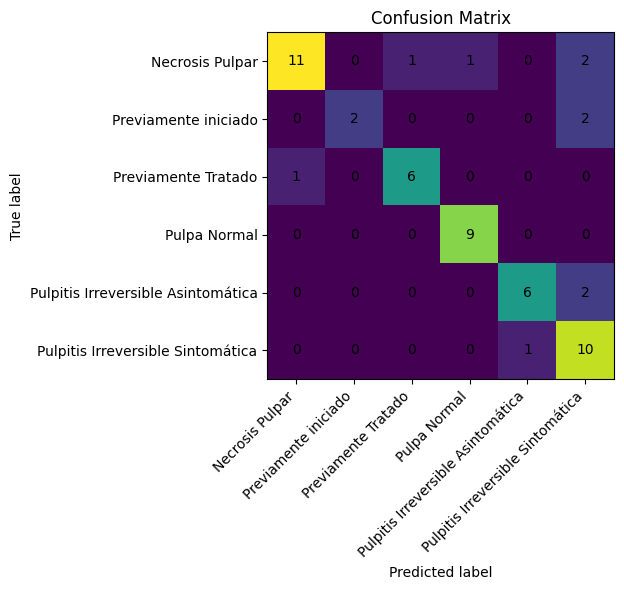

In [35]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results["confusion_matrix"], idx_to_class)


In [36]:
from collections import Counter

test_loader = data_module["loaders"]["test"]

loader_labels = []

for images, clinical_vectors, labels in test_loader:
    loader_labels.extend(labels.numpy().tolist())

print("Total labels desde test_loader:", len(loader_labels))
print("Distribución desde test_loader:")

for class_idx, count in sorted(Counter(loader_labels).items()):
    print(class_idx, idx_to_class[class_idx], count)

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_67337/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Total labels desde test_loader: 54
Distribución desde test_loader:
0 Necrosis Pulpar 15
1 Previamente iniciado 4
2 Previamente Tratado 7
3 Pulpa Normal 9
4 Pulpitis Irreversible Asintomática 8
5 Pulpitis Irreversible Sintomática 11


# Export the model

In [37]:
import torch
from pathlib import Path

save_dir = Path("saved_models")
save_dir.mkdir(exist_ok=True)

checkpoint = {
    "model_state_dict": train_full_model.state_dict(),
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "metrics": {
        "accuracy": results["accuracy"],
        "precision_macro": results["precision_macro"],
        "recall_macro": results["recall_macro"],
        "f1_macro": results["f1_macro"],
        "precision_weighted": results["precision_weighted"],
        "recall_weighted": results["recall_weighted"],
        "f1_weighted": results["f1_weighted"],
    },
}

torch.save(checkpoint, save_dir / "DentalDeepGAFullT1.pth")

In [38]:
checkpoint = torch.load("saved_models/DentalDeepGAFullT1.pth", map_location=device)


model = train_full_model 

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

class_to_idx = checkpoint["class_to_idx"]
idx_to_class = checkpoint["idx_to_class"]

In [39]:
from pathlib import Path
import torch

export_path = Path("Models/DentalDeepGAFullT1_model.pt2")
export_path.parent.mkdir(parents=True, exist_ok=True)

model_to_export = train_full_model.eval().to("cpu")

dummy_image = torch.randn(1, 1, 128, 128)
dummy_clinical = torch.randn(1, 11)

with torch.no_grad():
    exported_program = torch.export.export(
        model_to_export,
        (dummy_image, dummy_clinical),
    )

torch.export.save(
    exported_program,
    str(export_path),
)

print(f"Modelo exportado correctamente a: {export_path}")

Modelo exportado correctamente a: Models/DentalDeepGAFullT1_model.pt2


# Test the load model

In [40]:
import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)


def load_pt2_for_inference(path, device):
    exported_program = torch.export.load(path)
    model = exported_program.module()
    model = model.to(device)
    return model


@torch.inference_mode()
def get_predictions(model, loader, device):
    all_preds = []
    all_targets = []

    for images, clinical_vectors, labels in loader:
        images = images.to(device, non_blocking=True)
        clinical_vectors = clinical_vectors.to(device, non_blocking=True)

        for i in range(images.size(0)):
            image_i = images[i:i+1]
            clinical_i = clinical_vectors[i:i+1]

            logits = model(image_i, clinical_i)
            pred = torch.argmax(logits, dim=1).item()

            all_preds.append(pred)
            all_targets.append(labels[i].item())

    return np.array(all_targets), np.array(all_preds)


def evaluate_classification_model(model, loader, device, idx_to_class):
    y_true, y_pred = get_predictions(model, loader, device)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [41]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model_pt2 = load_pt2_for_inference(
    "Models/DentalDeepGAFull50_model.pt2",
    device=device,
)

results = evaluate_classification_model(
    model=model_pt2,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print("Accuracy:", results["accuracy"])
print("F1 macro:", results["f1_macro"])
print(results["classification_report"])

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/export/pt2_archive/_package.py:790: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:1592.)
  tensor = torch.frombuffer(
/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_67337/2383641742.p

Accuracy: 0.6851851851851852
F1 macro: 0.6717338217338217
                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.82      0.60      0.69        15
              Previamente iniciado       1.00      0.50      0.67         4
               Previamente Tratado       0.67      0.29      0.40         7
                      Pulpa Normal       1.00      1.00      1.00         9
Pulpitis Irreversible Asintomática       0.58      0.88      0.70         8
 Pulpitis Irreversible Sintomática       0.47      0.73      0.57        11

                          accuracy                           0.69        54
                         macro avg       0.76      0.66      0.67        54
                      weighted avg       0.74      0.69      0.68        54



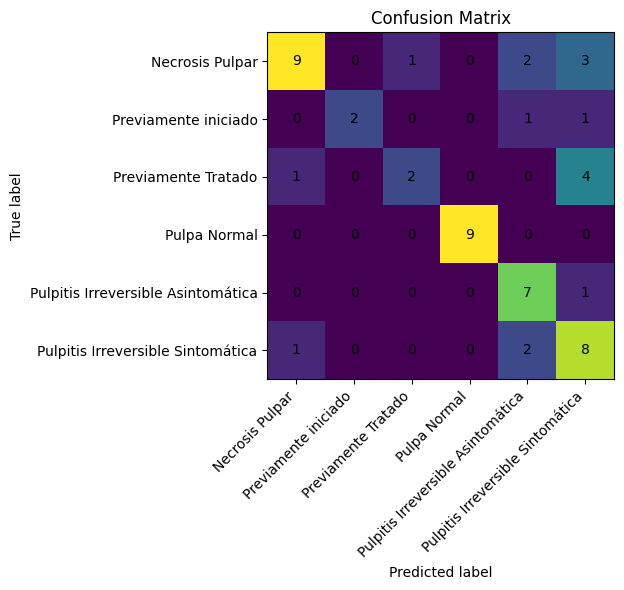

In [42]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results["confusion_matrix"], idx_to_class)
